# VGG16 on Skin Cancer (ISIC) — 4-Class Classification

Same dataset and same 4 classes as the AlexNet notebook, just a different model.

This notebook:
- Downloads the dataset **directly into Colab** via `kagglehub` (no `kaggle.json` file — you'll just paste your Kaggle username + API key once when prompted).
- Picks **4 classes** (edit `SELECTED_CLASSES` below if you want specific ones — keep it the same as your AlexNet run for a fair comparison).
- Trains **VGG16** (pretrained on ImageNet, fine-tuned).
- Reports **Accuracy, Precision, Recall, F1-Score, AUC** on a held-out test set.

Set Colab's runtime to **GPU** first: `Runtime > Change runtime type > T4 GPU`.

In [ ]:
!pip install -q kagglehub scikit-learn seaborn

## 1. Download dataset via kagglehub
First run will ask you to authenticate. Go to https://www.kaggle.com/settings -> **API** -> **Create New Token** — copy-paste the username and key it shows you. No file download needed.

In [ ]:
import kagglehub

path = kagglehub.dataset_download("nodoubttome/skin-cancer9-classesisic")
print("Dataset downloaded to:", path)

Using Colab cache for faster access to the 'skin-cancer9-classesisic' dataset.
Dataset downloaded to: /kaggle/input/skin-cancer9-classesisic


## 2. Find the class folders and select 4 classes

In [ ]:
import os, glob

candidate_dirs = [d for d in glob.glob(os.path.join(path, '**'), recursive=True) if os.path.isdir(d)]
class_dir, all_classes = None, []
for d in sorted(candidate_dirs, key=lambda x: x.count(os.sep)):
    subdirs = sorted([s for s in os.listdir(d) if os.path.isdir(os.path.join(d, s))])
    if len(subdirs) >= 4:
        class_dir, all_classes = d, subdirs
        break

print("Class folder:", class_dir)
print("All classes found:", all_classes)

# ---- EDIT THIS LIST if you want specific classes (use the SAME 4 as your AlexNet run) ----
SELECTED_CLASSES = all_classes[:4]
print("\nSelected classes for training:", SELECTED_CLASSES)

Class folder: /kaggle/input/skin-cancer9-classesisic/Skin cancer ISIC The International Skin Imaging Collaboration/Test
All classes found: ['actinic keratosis', 'basal cell carcinoma', 'dermatofibroma', 'melanoma', 'nevus', 'pigmented benign keratosis', 'seborrheic keratosis', 'squamous cell carcinoma', 'vascular lesion']

Selected classes for training: ['actinic keratosis', 'basal cell carcinoma', 'dermatofibroma', 'melanoma']


In [ ]:
import shutil

filtered_dir = "/content/filtered_dataset"
if os.path.exists(filtered_dir):
    shutil.rmtree(filtered_dir)
os.makedirs(filtered_dir)

for cls in SELECTED_CLASSES:
    os.symlink(os.path.join(class_dir, cls), os.path.join(filtered_dir, cls))

print("Filtered 4-class dataset ready at:", filtered_dir)

Filtered 4-class dataset ready at: /content/filtered_dataset


## 3. Build datasets & dataloaders
VGG16 expects **224x224** input (AlexNet used 227x227).

In [ ]:
import torch
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, random_split

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

full_dataset = datasets.ImageFolder(filtered_dir, transform=transform)
class_names = full_dataset.classes
print("Class-to-index mapping:", full_dataset.class_to_idx)

train_size = int(0.7 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

train_ds, val_ds, test_ds = random_split(
    full_dataset, [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

BATCH_SIZE = 32
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Train: {len(train_ds)}  Val: {len(val_ds)}  Test: {len(test_ds)}")

Class-to-index mapping: {'actinic keratosis': 0, 'basal cell carcinoma': 1, 'dermatofibroma': 2, 'melanoma': 3}
Train: 44  Val: 9  Test: 11


## 4. Load VGG16 and adapt the final layer to 4 classes

In [ ]:
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
model.classifier[6] = nn.Linear(4096, len(class_names))
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

Using device: cuda


## 5. Train
VGG16 is bigger than AlexNet, so each epoch will take longer — that's normal.

In [ ]:
EPOCHS = 10

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.set_grad_enabled(train):
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            if train:
                optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            if train:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * imgs.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)
    return total_loss / total, correct / total

for epoch in range(EPOCHS):
    train_loss, train_acc = run_epoch(train_loader, train=True)
    val_loss, val_acc = run_epoch(val_loader, train=False)
    print(f"Epoch {epoch+1}/{EPOCHS}  train_loss={train_loss:.4f} train_acc={train_acc:.4f}  val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

Epoch 1/10  train_loss=1.3253 train_acc=0.3182  val_loss=1.2149 val_acc=0.4444
Epoch 2/10  train_loss=1.0288 train_acc=0.5909  val_loss=0.8657 val_acc=0.7778
Epoch 3/10  train_loss=0.7773 train_acc=0.7955  val_loss=0.5308 val_acc=0.7778
Epoch 4/10  train_loss=0.3245 train_acc=0.9318  val_loss=0.3823 val_acc=0.7778
Epoch 5/10  train_loss=0.1342 train_acc=0.9545  val_loss=0.4148 val_acc=0.7778
Epoch 6/10  train_loss=0.0505 train_acc=0.9773  val_loss=0.2284 val_acc=0.8889
Epoch 7/10  train_loss=0.1680 train_acc=0.9545  val_loss=0.2125 val_acc=0.8889
Epoch 8/10  train_loss=0.0590 train_acc=0.9773  val_loss=0.4088 val_acc=0.8889
Epoch 9/10  train_loss=0.0582 train_acc=0.9773  val_loss=0.8552 val_acc=0.7778
Epoch 10/10  train_loss=0.0777 train_acc=0.9773  val_loss=0.7930 val_acc=0.6667


## 6. Evaluate on the test set: Accuracy, Precision, Recall, F1, AUC

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize

model.eval()
all_labels, all_preds, all_probs = [], [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        probs = torch.softmax(outputs, dim=1).cpu().numpy()
        preds = probs.argmax(1)
        all_labels.extend(labels.numpy())
        all_preds.extend(preds)
        all_probs.extend(probs)

all_labels = np.array(all_labels)
all_preds = np.array(all_preds)
all_probs = np.array(all_probs)

acc = accuracy_score(all_labels, all_preds) * 100
prec = precision_score(all_labels, all_preds, average='macro', zero_division=0) * 100
rec = recall_score(all_labels, all_preds, average='macro', zero_division=0) * 100
f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0) * 100

y_bin = label_binarize(all_labels, classes=list(range(len(class_names))))
try:
    auc = roc_auc_score(y_bin, all_probs, average='macro', multi_class='ovr') * 100
except Exception as e:
    auc = float('nan')
    print("AUC could not be computed:", e)

print("\n==== VGG16 Test Results (4 classes) ====")
print(f"Accuracy  : {acc:.2f}%")
print(f"Precision : {prec:.2f}%")
print(f"Recall    : {rec:.2f}%")
print(f"F1-Score  : {f1:.2f}%")
print(f"AUC       : {auc:.2f}%")


==== VGG16 Test Results (4 classes) ====
Accuracy  : 81.82%
Precision : 87.50%
Recall    : 87.50%
F1-Score  : 84.52%
AUC       : 97.32%


## 7. (Optional) Confusion matrix

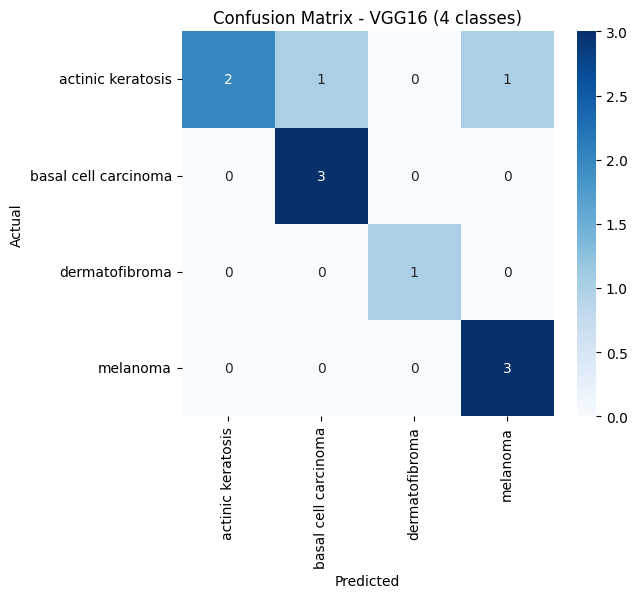

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - VGG16 (4 classes)")
plt.show()